# Лабораторная работа №3
## Исследование скрытых характеристик сигналов электроэнцефалографии

В данной работе используется запись `eeg1.edf`, аннотация `annotations_2017_C.csv` и файл `clinical_information.csv`.

Цель эксперимента — выделить приступный интервал, построить временную зависимость ЭЭГ во время приступа, усреднить все EEG-каналы, удалить частоты выше 60 Гц и для полученного сигнала построить спектрограмму и вейвлет-скейлограмму.

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import mne

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

Подключены библиотеки для обработки EEG-сигнала, визуализации и вычисления частотных представлений.  
Библиотека `mne` используется для чтения EDF-файла, а `scipy.signal` — для цифровой фильтрации и построения спектрограммы.

In [3]:
INPUT_ROOT = Path("/kaggle/input")

def find_file(filename: str, root: Path = INPUT_ROOT) -> Path:
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Файл {filename} не найден внутри {root}")
    return matches[0]

edf_path = find_file("eeg1.edf")
ann_path = find_file("annotations_2017_C.csv")
clinical_path = find_file("clinical_information.csv")

print("EDF:", edf_path)
print("Annotations:", ann_path)
print("Clinical info:", clinical_path)

EDF: /kaggle/input/datasets/abokarim/eeg-ali-saleh-01/eeg1.edf
Annotations: /kaggle/input/datasets/abokarim/eeg-ali-saleh-01/annotations_2017_C.csv
Clinical info: /kaggle/input/datasets/abokarim/eeg-ali-saleh-01/clinical_information.csv


На данном этапе автоматически находятся все необходимые файлы внутри директории `/kaggle/input`.  
Такой подход делает код воспроизводимым без жёсткой привязки к конкретному имени датасета.

In [4]:
clinical_df = pd.read_csv(clinical_path)
annotations_df = pd.read_csv(ann_path)

record_name = "eeg1"
record_row = clinical_df.loc[clinical_df["EEG file"] == record_name].iloc[0]
record_id = int(record_row["ID"])

print("Соответствие записи и идентификатора:")
display(record_row.to_frame().T[["ID", "EEG file", "Diagnosis", "Number of Reviewers Annotating Seizure"]])

ann_series = annotations_df[str(record_id)].fillna(0).astype(int)

Соответствие записи и идентификатора:


,ID,EEG file,Diagnosis,Number of Reviewers Annotating Seizure
0,1,eeg1,mild/moderate asphyxia,3


In [5]:
def get_intervals(binary_series):
    intervals = []
    in_run = False
    start = None
    
    for i, value in enumerate(binary_series):
        if value == 1 and not in_run:
            start = i
            in_run = True
        elif value == 0 and in_run:
            intervals.append((start, i - 1, i - start))
            in_run = False
    
    if in_run:
        intervals.append((start, len(binary_series) - 1, len(binary_series) - start))
    
    return intervals

all_intervals = get_intervals(ann_series.values)
intervals_df = pd.DataFrame(all_intervals, columns=["start_sec", "end_sec", "duration_sec"])
intervals_df = intervals_df.sort_values(["duration_sec", "start_sec"], ascending=[False, True]).reset_index(drop=True)

print("Найденные приступные интервалы по annotations_2017_C.csv:")
display(intervals_df.head(10))

Найденные приступные интервалы по annotations_2017_C.csv:


,start_sec,end_sec,duration_sec
0,328,447,120
1,1005,1109,105
2,6603,6700,98
3,4421,4493,73
4,6183,6253,71
5,4065,4107,43
6,2531,2565,35
7,3065,3098,34
8,5242,5268,27
9,6270,6296,27


По файлу `clinical_information.csv` определяется идентификатор записи `eeg1`, после чего из `annotations_2017_C.csv` извлекается соответствующий столбец аннотаций.  
Аннотации заданы с шагом 1 секунда, поэтому интервалы приступов формируются как непрерывные последовательности единиц.

In [6]:
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
sfreq = raw.info["sfreq"]
duration_sec = raw.n_times / sfreq

eeg_channels = [ch for ch in raw.ch_names if ch.startswith("EEG")]
non_eeg_channels = [ch for ch in raw.ch_names if not ch.startswith("EEG")]

print(f"Частота дискретизации: {sfreq} Гц")
print(f"Длительность записи: {duration_sec:.1f} с")
print(f"Всего каналов: {len(raw.ch_names)}")
print(f"EEG-каналов: {len(eeg_channels)}")
print("Не-EEG каналы:", non_eeg_channels)

ann_series = ann_series.iloc[:int(duration_sec)].reset_index(drop=True)

all_intervals = get_intervals(ann_series.values)
intervals_df = pd.DataFrame(all_intervals, columns=["start_sec", "end_sec", "duration_sec"])
intervals_df = intervals_df.sort_values(["duration_sec", "start_sec"], ascending=[False, True]).reset_index(drop=True)

seizure_start, seizure_end, seizure_duration = intervals_df.iloc[0]
print(f"Выбранный приступный интервал: {seizure_start}-{seizure_end} с (длительность {seizure_duration} с)")

Частота дискретизации: 256.0 Гц
Длительность записи: 6993.0 с
Всего каналов: 21
EEG-каналов: 19
Не-EEG каналы: ['ECG EKG-REF', 'Resp Effort-REF']
Выбранный приступный интервал: 328-447 с (длительность 120 с)


В записи присутствуют не только EEG-каналы, но и служебные каналы, связанные с ЭКГ и дыханием.  
Для усреднения и последующего анализа используются только 19 каналов ЭЭГ, что соответствует формулировке задания.

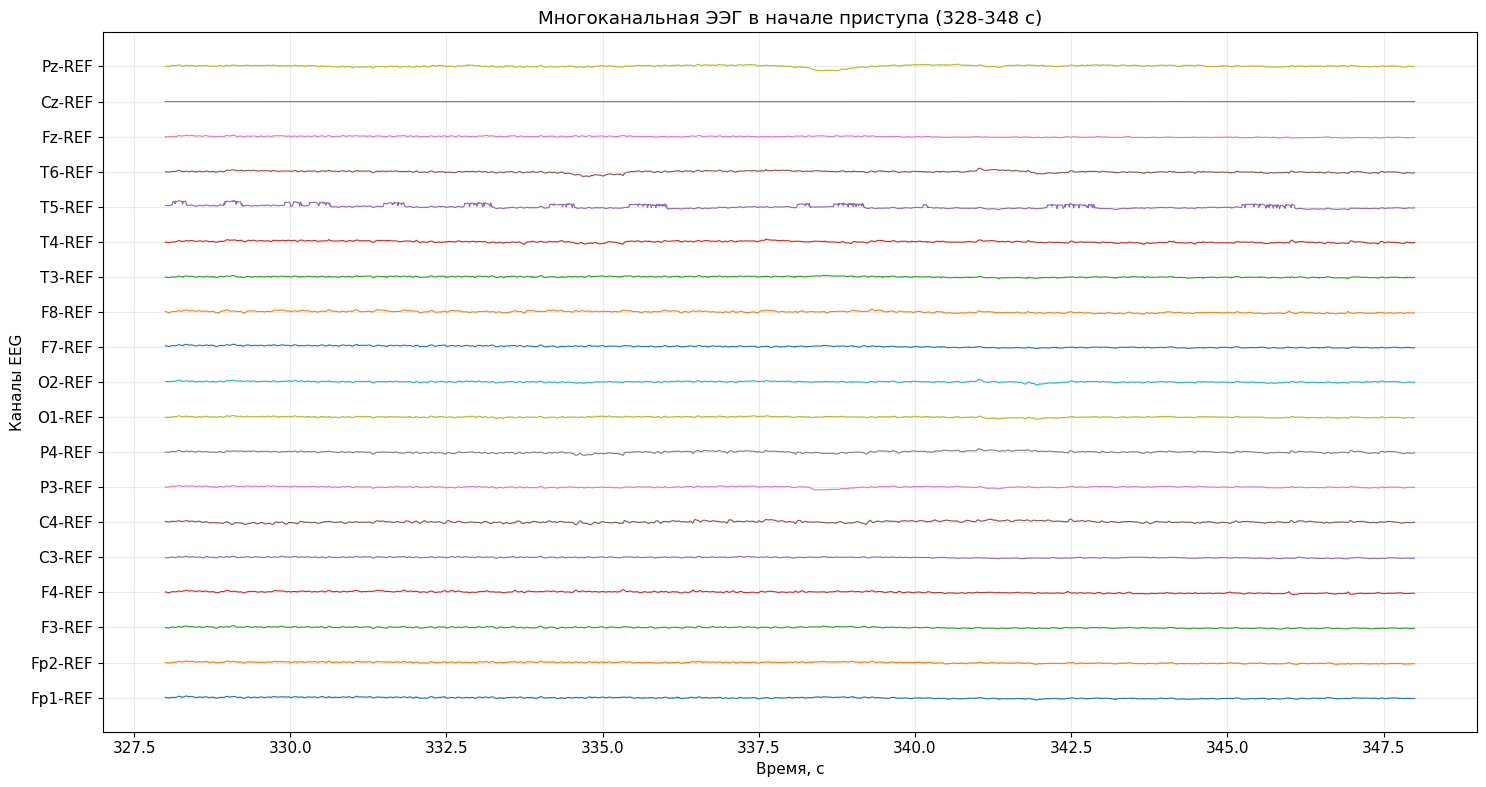

In [7]:
raw_eeg = raw.copy().pick(eeg_channels)
data_uv = raw_eeg.get_data() * 1e6  # перевод из В в мкВ

plot_start_sec = int(seizure_start)
plot_end_sec = min(int(seizure_start) + 20, int(seizure_end))

start_idx = int(plot_start_sec * sfreq)
end_idx = int(plot_end_sec * sfreq)

segment = data_uv[:, start_idx:end_idx]
time_segment = np.arange(start_idx, end_idx) / sfreq

offset_step = 300
plt.figure(figsize=(15, 8))

for i in range(segment.shape[0]):
    plt.plot(time_segment, segment[i] + i * offset_step, linewidth=0.8)

plt.yticks(
    [i * offset_step for i in range(len(eeg_channels))],
    [ch.replace("EEG ", "") for ch in eeg_channels]
)
plt.xlabel("Время, с")
plt.ylabel("Каналы EEG")
plt.title(f"Многоканальная ЭЭГ в начале приступа ({plot_start_sec}-{plot_end_sec} с)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("/kaggle/working/eeg_multichannel_seizure.png", dpi=300, bbox_inches="tight")
plt.show()

Построен временной график многоканальной ЭЭГ на приступном участке.  
Для повышения наглядности выбран укороченный фрагмент длиной 20 секунд от начала аннотированного приступа, а каналы разнесены по вертикали.

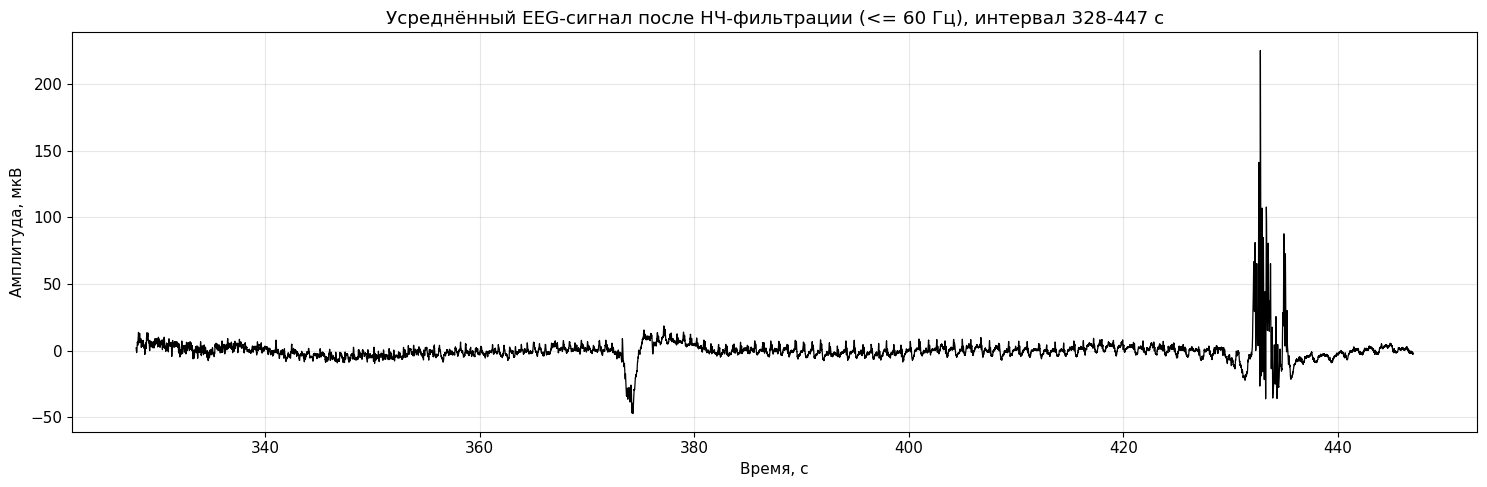

In [10]:
avg_signal_uv = data_uv.mean(axis=0)

sos = signal.butter(4, 60, btype="lowpass", fs=sfreq, output="sos")
avg_signal_filt_uv = signal.sosfiltfilt(sos, avg_signal_uv)

seizure_start_idx = int(seizure_start * sfreq)
seizure_end_idx = int(seizure_end * sfreq)

avg_seizure_uv = avg_signal_filt_uv[seizure_start_idx:seizure_end_idx]
time_seizure = np.arange(seizure_start_idx, seizure_end_idx) / sfreq

plt.figure(figsize=(15, 5))
plt.plot(time_seizure, avg_seizure_uv, color="black", linewidth=0.9)
plt.xlabel("Время, с")
plt.ylabel("Амплитуда, мкВ")
plt.title(f"Усреднённый EEG-сигнал после НЧ-фильтрации (<= 60 Гц), интервал {seizure_start}-{seizure_end} с")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/avg_eeg_filtered_seizure.png", dpi=300, bbox_inches="tight")
plt.show()

На данном этапе все EEG-каналы усредняются в один сигнал, после чего выполняется цифровая фильтрация низких частот с граничной частотой 60 Гц.  
Полученный одномерный сигнал используется как основа для спектрального и вейвлет-анализа.

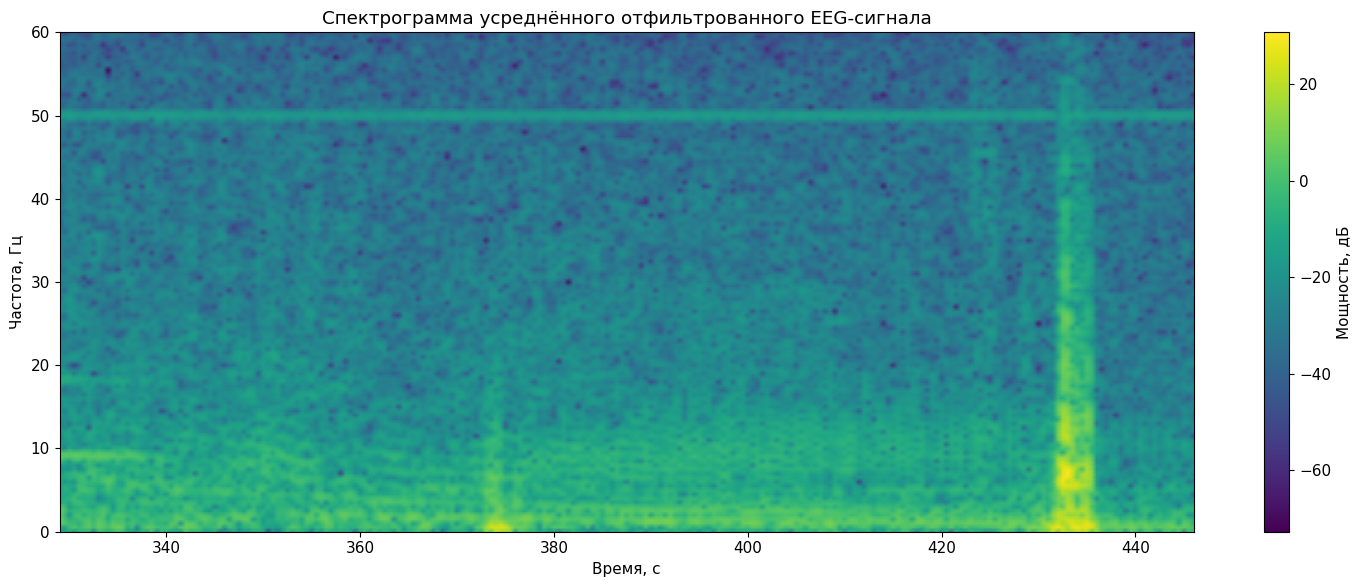

Доминирующая частота по средней спектральной мощности: 0.50 Гц


In [11]:
frequencies, times_spec, Sxx = signal.spectrogram(
    avg_seizure_uv,
    fs=sfreq,
    window="hann",
    nperseg=512,
    noverlap=384,
    scaling="density",
    mode="psd"
)

freq_mask = frequencies <= 60
frequencies = frequencies[freq_mask]
Sxx = Sxx[freq_mask, :]

mean_psd = Sxx.mean(axis=1)
dominant_freq = frequencies[np.argmax(mean_psd)]

plt.figure(figsize=(15, 6))
plt.pcolormesh(times_spec + seizure_start, frequencies, 10 * np.log10(Sxx + 1e-12), shading="gouraud")
plt.colorbar(label="Мощность, дБ")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.title("Спектрограмма усреднённого отфильтрованного EEG-сигнала")
plt.ylim(0, 60)
plt.tight_layout()
plt.savefig("/kaggle/working/eeg_spectrogram.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Доминирующая частота по средней спектральной мощности: {dominant_freq:.2f} Гц")

Построена спектрограмма усреднённого и отфильтрованного сигнала на приступном интервале.  
Спектрограмма позволяет оценить, как распределяется энергия сигнала по времени и частоте, а также выявить наиболее выраженные низкочастотные компоненты.

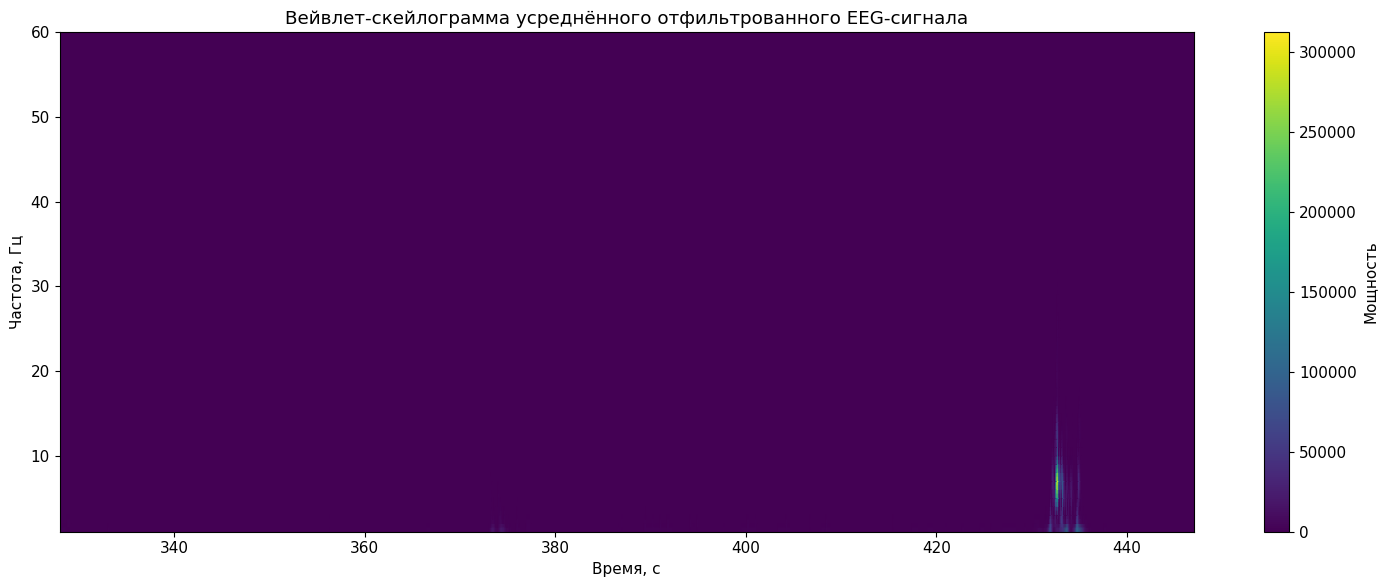

,band,peak_time_sec,peak_power
0,delta_1_4_Hz,434.859375,76781.216285
1,theta_4_8_Hz,432.757812,209195.625363
2,alpha_8_13_Hz,432.757812,136698.918593
3,beta_13_30_Hz,432.750000,11903.946626
4,gamma_30_60_Hz,432.765625,245.423430


In [12]:
freqs = np.arange(1, 61)
n_cycles = np.maximum(freqs / 2, 2)

power = mne.time_frequency.tfr_array_morlet(
    avg_seizure_uv[np.newaxis, np.newaxis, :],
    sfreq=sfreq,
    freqs=freqs,
    n_cycles=n_cycles,
    output="power",
    decim=2,
    n_jobs=1,
    verbose="ERROR"
)[0, 0]

time_wavelet = time_seizure[::2]

plt.figure(figsize=(15, 6))
plt.pcolormesh(time_wavelet, freqs, power, shading="gouraud")
plt.colorbar(label="Мощность")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.title("Вейвлет-скейлограмма усреднённого отфильтрованного EEG-сигнала")
plt.ylim(1, 60)
plt.tight_layout()
plt.savefig("/kaggle/working/eeg_scalogram.png", dpi=300, bbox_inches="tight")
plt.show()

band_definitions = {
    "delta_1_4_Hz": (1, 4),
    "theta_4_8_Hz": (4, 8),
    "alpha_8_13_Hz": (8, 13),
    "beta_13_30_Hz": (13, 30),
    "gamma_30_60_Hz": (30, 60),
}

band_peaks = []
for band_name, (f_low, f_high) in band_definitions.items():
    mask = (freqs >= f_low) & (freqs < f_high)
    band_series = power[mask].mean(axis=0)
    peak_idx = int(np.argmax(band_series))
    band_peaks.append({
        "band": band_name,
        "peak_time_sec": float(time_wavelet[peak_idx]),
        "peak_power": float(band_series[peak_idx])
    })

band_peaks_df = pd.DataFrame(band_peaks)
display(band_peaks_df)

Вейвлет-скейлограмма строится с использованием комплексного Morlet-вейвлета.  
В отличие от спектрограммы, этот метод лучше показывает локальные по времени изменения частотной структуры сигнала и позволяет точнее выделить кратковременные усиления в отдельных диапазонах частот.

In [14]:
summary_metrics = pd.DataFrame([
    {
        "record_name": record_name,
        "record_id": record_id,
        "sampling_rate_hz": float(sfreq),
        "duration_sec": float(duration_sec),
        "total_channels": int(len(raw.ch_names)),
        "eeg_channels": int(len(eeg_channels)),
        "chosen_seizure_start_sec": int(seizure_start),
        "chosen_seizure_end_sec": int(seizure_end),
        "chosen_seizure_duration_sec": int(seizure_duration),
        "dominant_frequency_hz": float(dominant_freq),
        "filtered_signal_mean_uv": float(avg_seizure_uv.mean()),
        "filtered_signal_std_uv": float(avg_seizure_uv.std()),
        "filtered_signal_min_uv": float(avg_seizure_uv.min()),
        "filtered_signal_max_uv": float(avg_seizure_uv.max())
    }
])

summary_metrics.to_csv("/kaggle/working/experiment3_metrics.csv", index=False)
intervals_df.to_csv("/kaggle/working/seizure_intervals_eeg1.csv", index=False)
band_peaks_df.to_csv("/kaggle/working/wavelet_band_peaks.csv", index=False)

display(summary_metrics)
print("Файлы сохранены в /kaggle/working:")
print("- eeg_multichannel_seizure.png")
print("- avg_eeg_filtered_seizure.png")
print("- eeg_spectrogram.png")
print("- eeg_scalogram.png")
print("- experiment3_metrics.csv")
print("- seizure_intervals_eeg1.csv")
print("- wavelet_band_peaks.csv")

,record_name,record_id,sampling_rate_hz,duration_sec,total_channels,eeg_channels,chosen_seizure_start_sec,chosen_seizure_end_sec,chosen_seizure_duration_sec,dominant_frequency_hz,filtered_signal_mean_uv,filtered_signal_std_uv,filtered_signal_min_uv,filtered_signal_max_uv
0,eeg1,1,256.0,6993.0,21,19,328,447,120,0.5,0.105557,8.838822,-47.112576,225.114279


Файлы сохранены в /kaggle/working:
- eeg_multichannel_seizure.png
- avg_eeg_filtered_seizure.png
- eeg_spectrogram.png
- eeg_scalogram.png
- experiment3_metrics.csv
- seizure_intervals_eeg1.csv
- wavelet_band_peaks.csv
